[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EelcoHoogendoorn/numga/blob/rewrite/rewrite/examples/mechanics/modes/modes.ipynb) [![Open in GitHub Codespaces](https://github.com/codespaces/badge.svg)](https://codespaces.new/EelcoHoogendoorn/numga?ref=rewrite)

# Planar Rigid-Body Stiffness, Inertia & Vibration Modes in PGA2D

When an elastic spring suspension supports a rigid body, its natural vibration frequencies and mode shapes depend on the interplay between elastic stiffness and mass inertia.

Rather than assembling coordinate mass and stiffness matrices by hand, this notebook uses **extensors** (linear maps between blade subspaces). In PGA, **both stiffness and inertia are purely additive quantities**: rank-1 spring lines compile directly into a **stiffness extensor**, mass points compile into an **inertia extensor** without origin choices or parallel-axis theorems, and normal vibration modes emerge from a single generalized eigensolve on their bilinear energy forms.


In [1]:
# Ensure the repository is importable in both local environments and Google Colab:
import sys
import os
import subprocess
from pathlib import Path

# Clone or update latest branch in Google Colab:
if 'google.colab' in sys.modules:
    os.chdir('/content')
    repo_dir = Path('/content/numga_repo')
    if not repo_dir.exists():
        subprocess.run(['git', 'clone', '--depth', '1', '-b', 'rewrite', 'https://github.com/EelcoHoogendoorn/numga.git', str(repo_dir)], check=True)
    else:
        subprocess.run(['git', '-C', str(repo_dir), 'pull', 'origin', 'rewrite'], check=True)
        for mod in list(sys.modules.keys()):
            if mod.startswith('examples') or mod.startswith('numga'):
                del sys.modules[mod]
    rewrite_dir = repo_dir / 'rewrite'
    src_dir = rewrite_dir / 'src'
    sys.path.insert(0, str(rewrite_dir))
    sys.path.insert(0, str(src_dir))

# Ensure rewrite/src and rewrite are at the front of sys.path when running locally:
for candidate_path in [Path.cwd(), *Path.cwd().parents]:
    rewrite_path = candidate_path / 'rewrite'
    if (rewrite_path / 'examples' / 'mechanics').is_dir():
        sys.path.insert(0, str(rewrite_path))
        sys.path.insert(0, str(rewrite_path / 'src'))
        break
    if (candidate_path / 'examples' / 'mechanics').is_dir():
        sys.path.insert(0, str(candidate_path))
        sys.path.insert(0, str(candidate_path / 'src'))
        break


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

from numga import NumpyContext
from numga.algebras import PGA2D
from examples.mechanics.modes.render import (
    render_setup,
    draw_modes,
    save_animation,
)
from examples.mechanics.modes.modes import mode_case

# Bind 2D Projective Geometric Algebra (PGA2D):
ctx = NumpyContext(PGA2D)
mv = ctx.multivector

# Blade Subspaces:
Scalar = PGA2D.gatype.scalar()              # Grade 0: scalar real values
Point = PGA2D.gatype.antivector()           # Grade 2: projective points in the 2D plane
Twist = PGA2D.gatype.bivector()             # Grade 2 dual / Lie algebra: infinitesimal rigid motions & velocities
Wrench = PGA2D.gatype.antibivector()        # Dual of Twist (bivector): forces, torques, and momentum lines

# Extensors (linear maps between blade subspaces):
SpringExtension = PGA2D.gatype((Scalar, Twist))   # Scalar <- Twist: measures spring extension from body motion
Stiffness = PGA2D.gatype((Wrench, Twist))         # Wrench <- Twist: restoring force and torque from body motion
Inertia = PGA2D.gatype((Wrench, Twist))           # Wrench <- Twist: kinetic momentum wrench from twist velocity

def point(xy: np.ndarray) -> Point:
    """Embed (..., 2) Cartesian positions as PGA points (dual of homogeneous vector)."""
    return (mv.x * xy[..., 0] + mv.y * xy[..., 1] + mv.w).dual()

## 1. Rigid Body Geometry, Masses & Springs

A 2x1 rectangular plate of mass 1 is suspended in the plane by two vertical elastic springs. All physical properties—geometry, lumped corner masses, and spring constants—are defined together in the preamble. In PGA, a spring is the directed line joining its anchor to its attachment point: `lines = (anchors & attachments).normalized()`.


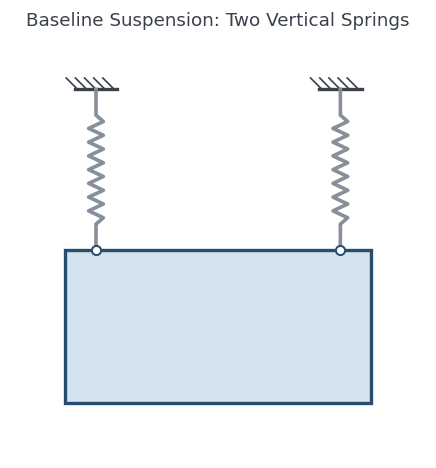

In [3]:
# 1. Rigid plate geometry (2x1 rectangle, center of mass at (1, 1)):
body = point(np.array([[0.0, 0.5], [2.0, 0.5], [2.0, 1.5], [0.0, 1.5]]))      # [4] Point
masses = np.full(4, 0.25)                                                      # [4] float (total mass = 1.0 kg)

# 2. Baseline suspension: two vertical springs:
attachments = point(np.array([[0.2, 1.5], [1.8, 1.5]]))                         # [2] Point
anchors = point(np.array([[0.2, 2.55], [1.8, 2.55]]))                           # [2] Point
spring_constants = np.array([6.0, 6.0])                                        # [2] float (k = 6 N/m)

# 3. Spring lines of action in PGA (directed line joining anchor to attachment):
lines = (anchors & attachments).normalized()                                   # [2] Wrench

# Plot 1: Setup - Rigid plate suspended by vertical springs at equilibrium
fig = render_setup(
    body=body,
    anchors=anchors,
    attachments=attachments,
    title="Baseline Suspension: Two Vertical Springs",
)
plt.show()

## 2. Building the Inertia Extensor from Mass Points

An **extensor** is a coordinate-free linear map between blade subspaces. In NumGA, leaving a subspace argument open (such as `Twist`) compiles an operator rather than evaluating a single numerical product.

Here we construct the body's inertia extensor step by step:
1. **Velocity map**: An open twist in the Lie bracket `body.commutator(Twist)` produces an extensor mapping body velocity to the physical velocity vector of each point (`Point <- Twist`).
2. **Momentum lines**: Joining each point with its velocity map `body & velocities` produces a momentum line (`Wrench <- Twist`), scaled by point mass.
3. **Total inertia**: Summing the point extensors yields the rigid body's complete inertia operator without manually applying Steiner's parallel-axis theorem.


In [4]:
# 1. Direction of motion (velocity) of each point under an open twist:
#    Passing the GAType 'Twist' leaves the argument open, compiling a linear operator Point <- Twist:
velocities = body.commutator(Twist)                                            # [4] Point <- Twist

# 2. Join each point with its velocity map to form momentum lines, scaled by mass:
#    In PGA, linear momentum is a line of action with magnitude m*v (Wrench <- Twist):
point_momenta = (body & velocities) * masses                                   # [4] Wrench <- Twist

# 3. Inertia is purely additive: summing point extensors yields total rigid body inertia:
#    Total mass, center of mass, and rotational inertia are synthesized automatically:
inertia = point_momenta.sum(axis=0)                                            # [] Wrench <- Twist

print("Rigid body inertia matrix (3x3):\n", np.round(inertia.kernel, 3))

Rigid body inertia matrix (3x3):
 [[ 1.    0.   -1.  ]
 [ 0.    1.   -1.  ]
 [-1.   -1.    3.25]]


## 3. Building the Stiffness Extensor from Springs

Stiffness follows the exact same structural pattern as inertia. Instead of joining points with velocity maps, we pair spring lines with displacement twists to measure stretch, scale by stiffness, and sum:

1. **Extension linear form**: Contracting a spring line with an open twist `Twist & lines` yields a linear measurement form (`Scalar <- Twist`) measuring elongation.
2. **Hooke's law dyads**: Multiplying the line of action by extension and spring constant produces a restoring wrench dyad (`Wrench <- Twist`).
3. **Total stiffness**: Summing individual spring dyads yields total stiffness without selecting a reference origin.


In [5]:
# 1. Pairing an open twist with each spring line measures linear stretch (Scalar <- Twist):
#    Passing 'Twist' as an open operand compiles a linear form evaluating stretch from body motion:
extension = Twist & lines                                                      # [2] Scalar <- Twist

# 2. Hooke's law: line of action scaled by extension and spring constant (Wrench <- Twist):
#    Each spring defines an independent rank-1 extensor dyad mapping body motion to restoring wrench:
spring_stiffness = lines * extension * spring_constants                         # [2] Wrench <- Twist

# 3. Stiffness is purely additive: summing spring dyads naturally combines forces and torques:
stiffness = spring_stiffness.sum(axis=0)                                       # [] Wrench <- Twist

print("Total stiffness matrix (3x3):\n", np.round(stiffness.kernel, 3))

Total stiffness matrix (3x3):
 [[ 12.     0.   -12.  ]
 [  0.     0.     0.  ]
 [-12.     0.    19.68]]


## 4. Energy Bilinear Forms & Modal Eigensolve

Natural vibration modes solve the generalized eigenvalue problem between elastic potential energy and kinetic energy: `pe_form.eigh(ke_form)`.


=== Baseline Suspension: Two Vertical Springs ===
  Free slide      : 0.00 Hz (free mechanism)
  Rock            : 0.394 Hz
  Bounce          : 0.551 Hz


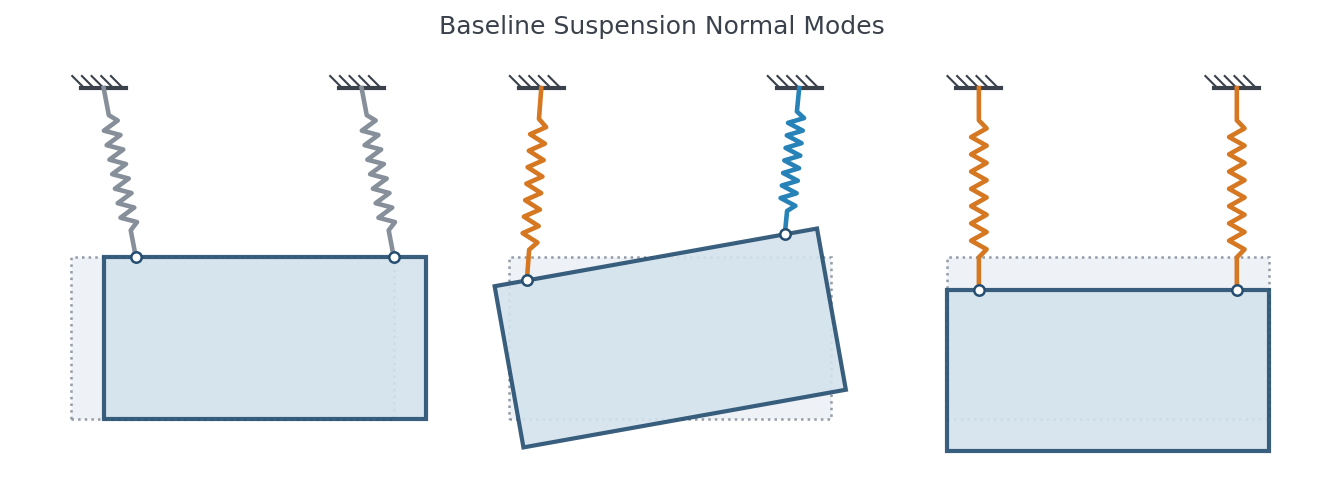

In [6]:
# 1. Form symmetric energy bilinear forms:
#    stiffness and inertia map Wrench <- Twist. Contracting with an open twist via regressive
#    product (&) yields symmetric bilinear forms for potential and kinetic energy without
#    forming the asymmetric coordinate product M^-1 @ K:
pe_form = Twist & stiffness                                                    # [] Scalar <- (Twist, Twist)
ke_form = Twist & inertia                                                      # [] Scalar <- (Twist, Twist)

# 2. Solve generalized symmetric eigenvalue problem directly on bilinear energy forms:
#    Dispatches to eigh_forms (Hermitian generalized eigensolve: K*v = lambda*M*v):
values, modes = pe_form.eigh(ke_form)                                          # values: [3] Scalar, modes: [3] Twist

# 3. Natural frequencies in Hz: f = sqrt(lambda) / (2 * pi) via scalar extension methods:
frequencies = values.clip(0, np.inf).square_root() / (2 * np.pi)               # [3] Scalar

print("=== Baseline Suspension: Two Vertical Springs ===")
for label, freq in zip(["Free slide", "Rock", "Bounce"], frequencies.to_array()):
    detail = "0.00 Hz (free mechanism)" if freq == 0 else f"{freq:.3f} Hz"
    print(f"  {label:<16}: {detail}")

# 4. Evaluate physical displacements via Lie algebra commutator and spring extensions:
body_offsets = body[None, :].commutator(modes[:, None])                        # [3, 4] Point
attachment_offsets = attachments[None, :].commutator(modes[:, None])          # [3, 2] Point
extensions = extension(modes[:, None])                                         # [3, 2] Scalar

# Plot 3: 3-Panel Baseline Mode Shapes (Uncoupled Motions)
case_baseline = mode_case(
    body=body,
    attachments=attachments,
    anchors=anchors,
    values=values,
    body_offsets=body_offsets,
    attachment_offsets=attachment_offsets,
    extensions=extensions,
)
fig = draw_modes([case_baseline], title="Baseline Suspension Normal Modes")
plt.show()

## 5. Adding an Angled Spring: Additivity in Action

Adding an off-center angled spring breaks symmetry, eliminates the 0 Hz free slide, and couples horizontal, vertical, and rocking motions.


=== Coupled Suspension: Added Angled Spring ===
  Coupled mode 1  : 0.212 Hz
  Coupled mode 2  : 0.447 Hz
  Coupled mode 3  : 0.651 Hz


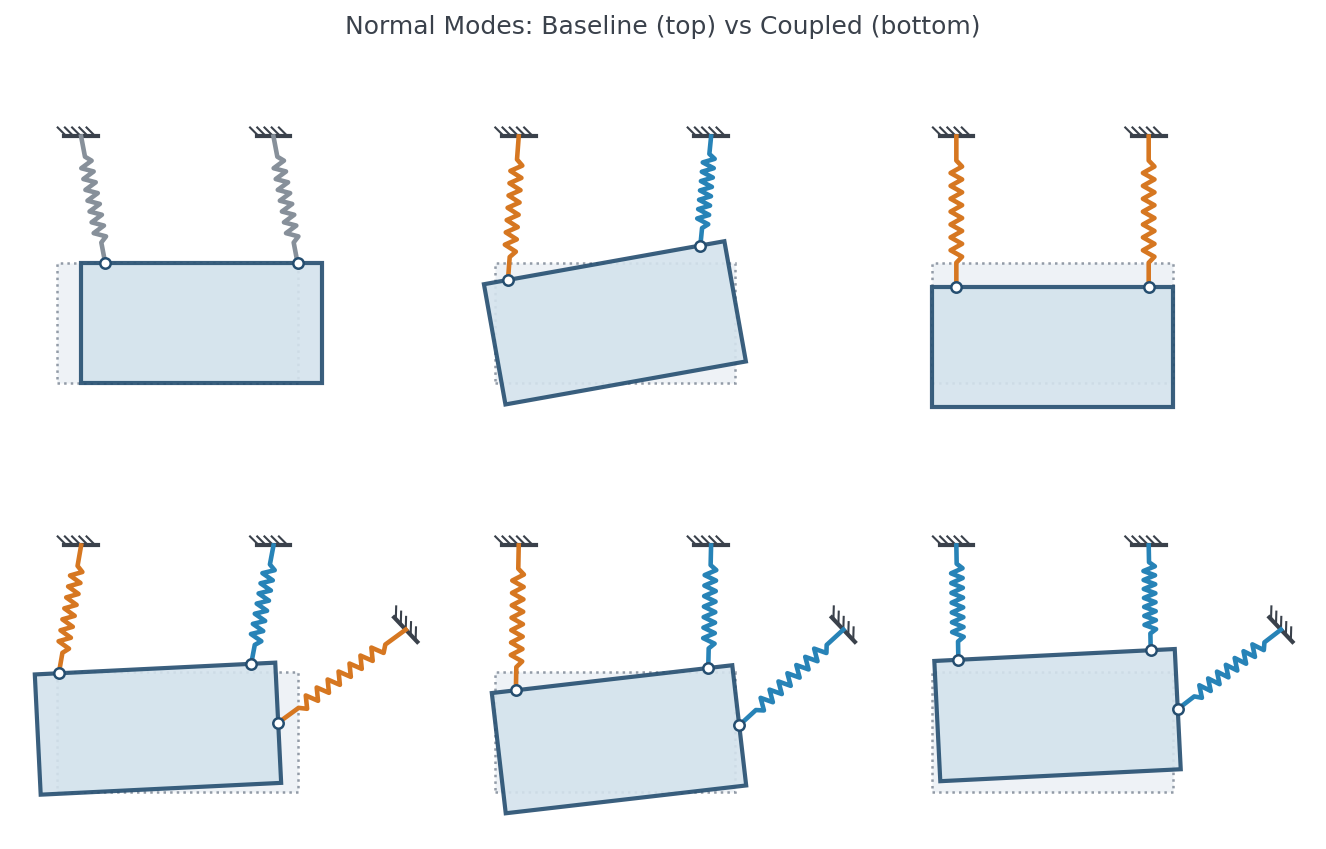

In [7]:
# 1. Define the third off-center angled spring:
attachment_extra = point(np.array([2.0, 1.0]))                                # [] Point
anchor_extra = point(np.array([2.9, 1.85]))                                   # [] Point
line_extra = (anchor_extra & attachment_extra).normalized()                   # [] Wrench
extension_extra = Twist & line_extra                                           # [] Scalar <- Twist
spring_extra = line_extra * 6.0 * extension_extra                             # [] Wrench <- Twist

# 2. Additivity in action: add the new spring extensor directly to existing stiffness:
#    No coordinate projections or origin shifts required; total stiffness is a direct sum:
stiffness_coupled = stiffness + spring_extra                                   # [] Wrench <- Twist

# 3. Form the updated symmetric potential energy form and solve the generalized eigensolve:
pe_form_coupled = Twist & stiffness_coupled                                    # [] Scalar <- (Twist, Twist)
values_coupled, modes_coupled = pe_form_coupled.eigh(ke_form)                  # values: [3] Scalar, modes: [3] Twist
frequencies_coupled = values_coupled.clip(0, np.inf).square_root() / (2 * np.pi)  # [3] Scalar

print("=== Coupled Suspension: Added Angled Spring ===")
for label, freq in zip(["Coupled mode 1", "Coupled mode 2", "Coupled mode 3"], frequencies_coupled.to_array()):
    print(f"  {label:<16}: {freq:.3f} Hz")

# Combine spring geometry for the 3-spring case:
attachments_coupled = point(np.array([[0.2, 1.5], [1.8, 1.5], [2.0, 1.0]]))  # [3] Point
anchors_coupled = point(np.array([[0.2, 2.55], [1.8, 2.55], [2.9, 1.85]]))   # [3] Point
lines_coupled = (anchors_coupled & attachments_coupled).normalized()           # [3] Wrench
extension_coupled = Twist & lines_coupled                                      # [3] Scalar <- Twist

# 4. Evaluate physical displacements and spring extensions for coupled modes:
body_offsets_coupled = body[None, :].commutator(modes_coupled[:, None])        # [3, 4] Point
attachment_offsets_coupled = attachments_coupled[None, :].commutator(modes_coupled[:, None])  # [3, 3] Point
extensions_coupled = extension_coupled(modes_coupled[:, None])                 # [3, 3] Scalar

case_coupled = mode_case(
    body=body,
    attachments=attachments_coupled,
    anchors=anchors_coupled,
    values=values_coupled,
    body_offsets=body_offsets_coupled,
    attachment_offsets=attachment_offsets_coupled,
    extensions=extensions_coupled,
)

# Plot 4: 6-Panel Mode Comparison - Baseline vs Coupled
fig = draw_modes([case_baseline, case_coupled], title="Normal Modes: Baseline (top) vs Coupled (bottom)")
plt.show()

## 6. Harmonic Oscillation Animation

Releasing the plate from rest in each mode demonstrates physical time evolution.


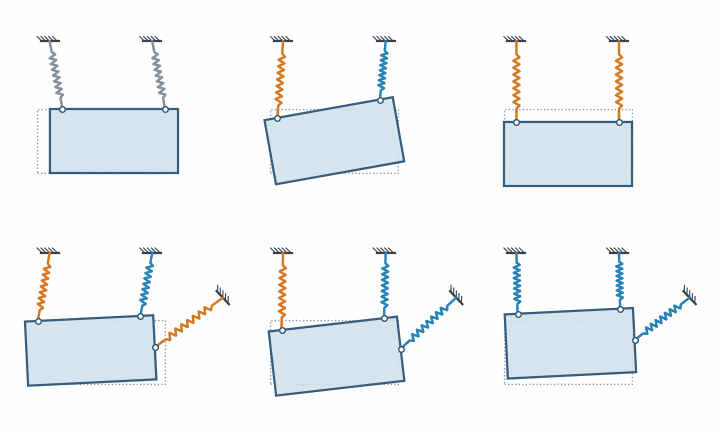

In [8]:
# Synchronized harmonic vibration animation:
gif = save_animation([case_baseline, case_coupled])
display(Image(filename=gif))

## 7. Summary & Conceptual Synthesis

Having walked through the working pipeline, we can step back and examine how **extensors** structure rigid-body mechanics:

* **Measuring Deformation with Lines (Spring Extension as a Linear Form)**:
  A spring is a line joining an anchor to an attachment point (`lines = anchors & attachments`). Pairing that line with an open twist (`Twist & lines`) directly yields a linear form (`Scalar <- Twist`) measuring spring stretch under any rigid body motion without coordinate projection formulas.

* **Additivity of Stiffness (Rank-1 Extensor Dyads)**:
  Each spring defines an independent rank-1 extensor dyad (`lines * (Twist & lines) * k`) mapping displacement twist to restoring wrench (`Wrench <- Twist`). Total stiffness is purely additive: summing individual spring extensors seamlessly combines linear forces and torques without choosing a reference origin. Adding a spring is literally adding its extensor.

* **Additivity of Inertia (Joining Points with Motion Lines)**:
  The commutator of a mass point with an open twist (`mass_points.commutator(Twist)`) gives its direction of motion. Joining the point with its velocity direction (`mass_points & velocities`) forms the line of action of its linear momentum (`Wrench <- Twist`). Summing across mass points synthesizes total mass, center of mass, and rotational inertia into one coordinate-free extensor without parallel-axis (Steiner) shifts.

* **Symmetrizing into Bilinear Energy Forms (Generalized Eigensolve)**:
  `stiffness` and `inertia` map `Wrench <- Twist`. Pairing their output wrench with an open twist (`Twist & stiffness`, `Twist & inertia`) contracts into a scalar, yielding symmetric bilinear energy forms (`Scalar <- Twist, Twist`) representing potential and kinetic energy. Solving `pe_form.eigh(ke_form)` computes real vibration frequencies and normal modes directly without inverting inertia or forming asymmetric coordinate matrices.

* **Evaluating Physical Displacements (Lie Algebra Commutators)**:
  The motion of any point on the rigid body under an eigenvector twist step is evaluated directly via the Lie algebra commutator (`body.commutator(modes)`), cleanly connecting abstract Lie algebra coordinates to physical geometry.
